In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/readme[1].txt
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/MSR-LA - 3467.docx
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/7981.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/6234.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/1269.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/3863.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/6241.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/10304.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/623.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/2193.jpg
/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/11925.jpg
/kaggle/input/datasets/shaunthesh

# Import Path

In [2]:
import os

path = '/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages'

if os.path.exists(path):
    print("Glad I found the right path.")
    print("Folders:", os.listdir(path))
else:
    print("Path is wrong.")

Glad I found the right path.
Folders: ['Dog', 'Cat']


# Clean the data

In [3]:
import tensorflow as tf
import os

data_dir = '/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/'

def load_and_clean_data(subset):
    return tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset=subset,
        seed=123,
        image_size=(128, 128),
        batch_size=32
    )

train_ds_raw = load_and_clean_data("training")
val_ds_raw = load_and_clean_data("validation")

def filter_corrupt_images(image, label):

    return tf.io.decode_image(tf.io.encode_jpeg(image), channels=3) is not None

train_ds = train_ds_raw.apply(tf.data.experimental.ignore_errors())
val_ds = val_ds_raw.apply(tf.data.experimental.ignore_errors())

print("Cleanup complete! Strat Training.")

2026-04-22 11:54:31.830038: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776858872.013593      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776858872.066924      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776858872.497290      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776858872.497341      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776858872.497344      55 computation_placer.cc:177] computation placer alr

Found 25000 files belonging to 2 classes.
Using 20000 files for training.


I0000 00:00:1776858906.331616      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 25000 files belonging to 2 classes.
Using 5000 files for validation.
Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.
Cleanup complete! Strat Training.


# Apply CNN and Rescaling

In [4]:
from tensorflow.keras import layers, models

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


# 4. Summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,993 (5.42 MB)

 Trainable params: 1,420,993 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

# Training

In [5]:
print("Training Started.")
history = model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=20)

Training Started.
Epoch 1/20


I0000 00:00:1776858942.850595     158 cuda_dnn.cc:529] Loaded cuDNN version 91002


      7/Unknown 6s 36ms/step - accuracy: 0.4996 - loss: 0.7074

Corrupt JPEG data: 162 extraneous bytes before marker 0xd9


     55/Unknown 9s 63ms/step - accuracy: 0.4938 - loss: 0.7001

...

600/619 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9029 - loss: 0.2297

Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


617/619 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9029 - loss: 0.2297

Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9


619/619 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.9029 - loss: 0.2297 - val_accuracy: 0.8899 - val_loss: 0.2633


# save model 



In [6]:
model.save('my_cats_vs_dogs_model.keras')
print("Model Save")

Model Save


# Model Accuracy.

In [7]:
loss, accuracy = model.evaluate(val_ds)

print(f"Final Accuracy: {accuracy * 100:.2f}%")

     10/Unknown 0s 22ms/step - accuracy: 0.9023 - loss: 0.2546

Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9


    100/Unknown 2s 22ms/step - accuracy: 0.8938 - loss: 0.2583

Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9


154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8932 - loss: 0.2578
Final Accuracy: 89.07%


# Accuracy Graph

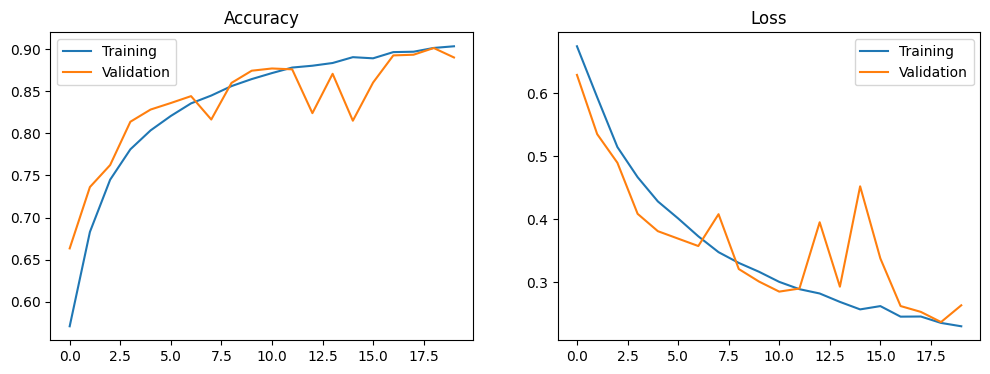

In [8]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training')
plt.plot(val_acc, label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training')
plt.plot(val_loss, label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

# Code For Cat and Dog Predict

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


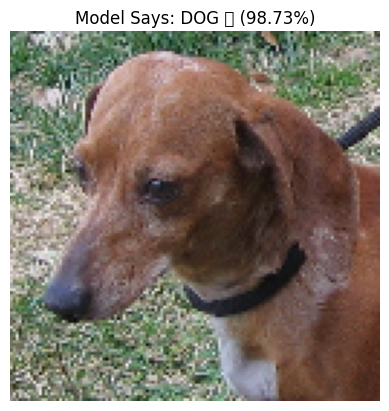

Raw Score: 0.9873


In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def final_test(image_path):
   
    img = tf.keras.utils.load_img(image_path, target_size=(128, 128))
    img_array = tf.keras.utils.img_to_array(img)
    
    
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Prediction
    prediction = model.predict(img_array)
    score = prediction[0][0]

    # 3. Decision Logic (0=Cat, 1=Dog)
    if score > 0.5:
        result = f"DOG 🐶 ({score*100:.2f}%)"
    else:
        result = f"CAT 🐱 ({(1-score)*100:.2f}%)"

    plt.imshow(img)
    plt.title(f"Model Says: {result}")
    plt.axis('off')
    plt.show()
    
    print(f"Raw Score: {score:.4f}")

final_test('/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/10011.jpg')